### HeroCoders Data Platform — Analysis

Layered analytics platform on Snowflake + dbt.  
Sources: Atlassian Marketplace (licenses + transactions) × Amplitude (product events).  
Pipeline: S3 raw → staging → intermediate → marts.

---

### 1. Exploratory Data Analysis

Initial profiling performed with [ydata-profiling](https://github.com/ydataai/ydata-profiling) (`home-task/eda/explore.py`).  
Reports saved to `home-task/eda/reports/`. Findings below.

---

**marketplace_licenses** &nbsp; *(3,017 rows)*

- `addon_license_id` is not unique — 79 values appear more than once; these are not full-row duplicates (maybe a join issue)
- `status` contains 6 variants across 3 logical states: `active`, `Active`, `ACTIVE`, `ACTV`, `expired`, `cancelled` (requires normalization)
- `hosting` contains `'data center'` (with space) alongside `'datacenter'`, `'cloud'`, `'server'`   
- `cloud_id` is null in 24.4% of records; `host_license_id` is populated in all rows across all hosting types
- `evaluation_license` is populated only on commercial records — points back to an originating eval `addon_license_id` (trial, demo, etc.)
- Campaign columns (`channel`, `campaign_*`, `referrer_domain`) are 40–60% null; license fields are fully populated (join issue?)

*Quick research points that cloud_id is Atlassian upcoming workspace ID, to deprecate host_license_id.*

---

**marketplace_transactions** &nbsp; *(4,029 rows)*

- 39 exact duplicate rows (1.0%)
- `manual_discount` is 0 across all rows
- 27% of transactions have `purchase_price = 0` — bundle deal or free tier? (needs clarification)
- Negative `purchase_price` values present — refunds?
- `billing_period` takes two values: `Annual`, `Monthly`
- `addon_license_id` joins to licenses at 100% — no orphaned transactions

---

**amplitude_events** &nbsp; *(~194k rows after deduplication)*

- 344 exact duplicate rows (0.4%)
- `device_id = 'bot-automation-001'` and `event_type = 'automated_test_run'` present in data
- `user_id` is null in 8.2% of events
- `user_property_plan` and `user_property_tier` contain blank strings and the literal `"None"` alongside true NULLs
- `user_property_company` null or invalid in ~10.5% of events
- No shared technical key with marketplace data — only available bridge is free-text company name

### 2. Ingestion & Pipeline Simulation

Production pipelines (Fivetran, Airbyte) extract from source systems and land files in S3 before transformation. This project simulates that pattern end-to-end.

---

**Infrastructure**  
Provisioned with Terraform: S3 bucket + IAM role with scoped read access for Snowflake.

**Raw layer — S3**  
Source CSVs serialised to JSONL.gz and pushed to S3 (`scripts/push_to_s3.py`).  
Files are immutable — reprocessing is always possible from source.

**Ingestion — Snowflake**  
External stage points to the S3 bucket.  
Raw files loaded into Snowflake via a dbt pre-hook macro — ingestion and transformation run in a single `dbt run`.

### 3. Staging Layer

One model per source. Deduplication, normalisation, and convenience flags — no business logic.

* *stg_marketplace_licenses*
* *stg_marketplace_transactions*
* *stg_amplitude_events*

**Basic tests applied:** Uniqueness, not null, identified constraints and FK relationships.

### 4. Assumptions & Definitions *(HeroCoders scope)*

**HeroCoders customers**  
A Jira workspace host_license_id subscribed to one or more HeroCoders addons.
Present across all hosting types (Cloud, Server, Data Center).
One company running two separate Jira sites = two customers.

**License**  
One workspace running one addon (host_license_id + addon_key).
A customer can partially churn (Checklist churns, Clockwork renews).

**Revenue history**  
Transactions — each renewal produces a new row. The licenses table reflects current state only.  
*marketplace_licenses* is always the most recent snapshot — license status changes over time are not captured. Depending on required latency, an event-based licenses table or dbt snapshots would enable full history and exact churn date detection.

**Joining marketplace and Amplitude**  
No shared key exists. Bridge: *company_key* — company name normalised to lowercase,
legal suffixes stripped, special characters replaced, ISO country appended.
Match rate: +95% on this dataset.

**Trial conversion**  
A commercial license where *evaluation_license* is not null — Atlassian's own FK
back to the originating eval. No fuzzy matching needed.

### 5. Intermediate Layer                                                                                                                                       
                                                                                                                                                                
Business logic lives here. Materialised as tables — reusable across marts, no raw column references downstream.                                                                                                                            
                                                                                                                                                              
* **int_customers** — one row per workspace; customer hub with product counts, active status, and normalised *company_key* for cross-source joining
* **int_trial_lifecycle** — one row per eval license; outcome classified as *converted*, *expired*, or *active_trial*; days to convert derived
* **int_monthly_mrr** — one row per transaction; MRR normalised to monthly value; renewal gap flag for churn detection
* **int_feature_usage** — one row per customer + product + event type + month; bot and test events excluded here; matched to known customers via *company_key*

### 6. Mart Layer

Aggregated, business-question grain. Each mart is the materialised answer to a specific question.

- *mart_active_customers* — active logos per product per month
- *mart_trial_conversion* — conversion rate by cohort month and product; days to convert
- *mart_mrr_churn* — MRR movements (new, renewal, expansion, contraction, reactivation), NRR, logo churn rate; split by *billing_period*
- *mart_feature_adoption* — feature usage linked to trial outcome (converted vs expired)
- *mart_customer_health* — composite health score per workspace; license status, MRR, feature engagement

---

### 7. Business Insights

Queries run against the mart layer in Snowflake. Connection reads credentials from `~/.dbt/profiles.yml`.

In [31]:
import warnings
warnings.filterwarnings('ignore')
import snowflake.connector
import pandas as pd
import plotly.express as px
import yaml, os

with open(os.path.expanduser('~/.dbt/profiles.yml'), 'r') as f:
    creds = yaml.safe_load(f)['herocoders']['outputs']['dev']

conn = snowflake.connector.connect(
    account   = creds['account'],
    user      = creds['user'],
    password  = creds['password'],
    role      = creds['role'],
    warehouse = creds['warehouse'],
    database  = creds['database'],
)

def query(sql):
    return pd.read_sql(sql, conn)

print("Connected ✓")

Connected ✓


#### How many active customers do we have per product, per month?

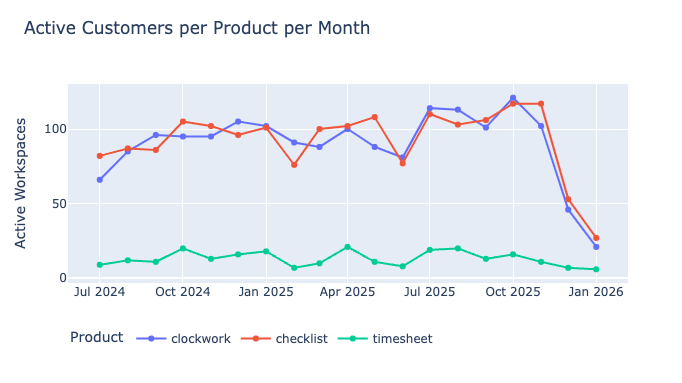

In [ ]:
df = query("""
    SELECT
        sale_month,
        addon_key,
        active_workspaces_per_product_month AS active_customers
    FROM MARTS.MART_ACTIVE_CUSTOMERS
    WHERE sale_month < DATE_TRUNC('month', CURRENT_DATE)
    GROUP BY 1, 2, 3
    ORDER BY 1
""")

df['SALE_MONTH'] = pd.to_datetime(df['SALE_MONTH'])
df['product'] = df['ADDON_KEY'].str.replace('com.herocoders.', '', regex=False)

fig = px.line(
    df, x='SALE_MONTH', y='ACTIVE_CUSTOMERS', color='product',
    title='Active Customers per Product per Month',
    labels={'SALE_MONTH': '', 'ACTIVE_CUSTOMERS': 'Active Workspaces', 'product': 'Product'},
    markers=True
)
fig.update_layout(width=720, height=380, legend=dict(orientation='h', y=-0.2))
fig.show()

#### What is our trial-to-paid conversion rate?

In [27]:
df = query("""
    SELECT
        addon_key,
        SUM(total_trials)                                           AS total_trials,
        SUM(converted_count)                                        AS converted,
        ROUND(AVG(avg_days_to_convert), 1)                         AS avg_days_to_convert
    FROM MARTS.MART_TRIAL_CONVERSION
    WHERE (converted_count + expired_count) > 0
    GROUP BY 1
""")

df['PRODUCT'] = df['ADDON_KEY'].str.replace('com.herocoders.', '', regex=False)
df['CONVERSION_RATE_%'] = (df['CONVERTED'] / df['TOTAL_TRIALS'] * 100).round(1)
df[['PRODUCT', 'TOTAL_TRIALS', 'CONVERTED', 'CONVERSION_RATE_%', 'AVG_DAYS_TO_CONVERT']]

,PRODUCT,TOTAL_TRIALS,CONVERTED,CONVERSION_RATE_%,AVG_DAYS_TO_CONVERT
0,clockwork,277,15,5.4,12.0
1,checklist,271,15,5.5,11.9
2,timesheet,15,3,20.0,18.3


#### What is our monthly churn rate and Net Revenue Retention (NRR)?

Monthly billing only — annual billing excluded as revenue is point-in-time, which would distort both metrics.

*beginning_mrr* is the prior month's closing MRR — the denominator that expresses retention as a rate.

> **Revenue note:** MRR is derived from *purchase_price* (gross). HeroCoders' actual retained revenue is *vendor_amount* — Atlassian deducts a marketplace fee before remittance. Current NRR reflects gross retention; a *vendor_amount*-based NRR would be lower.

> **Methodology note:** These are MoM snapshots, not cohort curves. At low logo counts, a single cancellation shifts the rate dramatically — so the figures below should be read as directional, not precise. A proper cohort retention analysis (tracking each acquisition cohort from month 0 through 12+) is the right instrument for measuring true retention health and LTV.

In [28]:
df = query("""
    SELECT
        sale_month,
        ROUND(SUM(total_mrr), 2)                                                AS total_mrr,
        ROUND(SUM(renewal_mrr + expansion_mrr - contraction_mrr)
              / NULLIF(SUM(beginning_mrr), 0) * 100, 1)                         AS nrr_pct,
        ROUND((1 - SUM(renewing_logos) / NULLIF(SUM(beginning_logos), 0)) * 100, 1) AS logo_churn_pct,
        SUM(new_logos)                                                          AS new_logos,
        SUM(total_logos)                                                        AS total_logos
    FROM MARTS.MART_MRR_CHURN
    WHERE billing_period = 'Monthly'
      AND sale_month >= DATEADD('month', -6, DATE_TRUNC('month', CURRENT_DATE))
      AND sale_month <  DATE_TRUNC('month', CURRENT_DATE)
    GROUP BY 1
    ORDER BY 1 DESC
""")

df

,SALE_MONTH,TOTAL_MRR,NRR_PCT,LOGO_CHURN_PCT,NEW_LOGOS,TOTAL_LOGOS
0,2026-01-01,1405.0,28.2,62.0,0,20
1,2025-12-01,4280.0,48.0,50.6,12,50
2,2025-11-01,7450.0,49.6,61.9,44,77
3,2025-10-01,7040.0,39.0,70.0,57,84
4,2025-09-01,6300.0,64.6,64.5,51,80


#### Which product features are most used by customers who convert vs. those who churn?

Compares average events per workspace during the trial period. Converted vs expired side by side — features with a large gap are the strongest conversion signals.

Top 3 features per product with the highest conversion signal ratio.

In [25]:
df = query("""                                                                                                                                                          
      WITH ranked AS (                                                                                                                                                    
          SELECT                                                                                                                                                          
              REPLACE(product, 'com.herocoders.', '')                    AS product,                                                                                      
              event_type,                                                                                                                                                 
              ROUND(MAX(CASE WHEN customer_cohort = 'converted'                                                                                                           
                             THEN avg_events_per_workspace END), 1)      AS converted,                                                                                    
              ROUND(MAX(CASE WHEN customer_cohort = 'expired'                                                                                                             
                             THEN avg_events_per_workspace END), 1)      AS expired,
              ROUND(MAX(CASE WHEN customer_cohort = 'converted'                                                                                                           
                             THEN avg_events_per_workspace END) /                                                                                                         
                    NULLIF(MAX(CASE WHEN customer_cohort = 'expired'
                             THEN avg_events_per_workspace END), 0), 1)  AS conversion_signal_ratio                                                                       
          FROM MARTS.MART_FEATURE_ADOPTION                                                                                                                                
          WHERE customer_cohort IN ('converted', 'expired')
          GROUP BY 1, 2                                                                                                                                                   
      )                                                                                                                                                                 
      SELECT
          product,
          event_type,
          converted,
          expired,                                                                                                                                                        
          conversion_signal_ratio,
          ROW_NUMBER() OVER (PARTITION BY product ORDER BY conversion_signal_ratio DESC) AS rn                                                                            
      FROM ranked  
      WHERE converted is not null                                                                                                                                                     
      QUALIFY rn <= 3
      ORDER BY product, conversion_signal_ratio DESC
  """)                                                                                                                                                                    
  
df[['PRODUCT', 'EVENT_TYPE', 'CONVERTED', 'EXPIRED', 'CONVERSION_SIGNAL_RATIO']]   


,PRODUCT,EVENT_TYPE,CONVERTED,EXPIRED,CONVERSION_SIGNAL_RATIO
0,checklist,checklist_item_created,3.5,1.4,2.5
1,checklist,checklist_item_completed,3.4,1.8,1.9
2,checklist,checklist_shared,3.3,1.8,1.8
3,clockwork,timer_started,3.0,1.9,1.6
4,clockwork,schedule_created,2.6,1.7,1.5
5,clockwork,timer_stopped,2.1,1.7,1.2
6,timesheet,timesheet_submitted,3.0,2.5,1.2
7,timesheet,subscription_cancelled,1.0,1.0,1.0
8,timesheet,trial_started,1.0,1.0,1.0


  ### 8. Key Findings                                                                                                                                                     
                                                                                                                                                                          
  **Cross-sell opportunity — multi-product adoption is near zero**                                                                                                        
  2,869 unique customers, only 25 (0.9%) hold more than one product.                                                                                               
                                                                                                                                                                        
  **Timesheet is smaller but its users are the most engaged**                                                                                                             
  195 customers vs ~1,350 for Checklist/Clockwork. Yet Timesheet averages ~4.6 monthly active users (MAU) per active license vs ~2.3 for the others — its users are twice 
  as embedded in their workflows. This might explain its higher conversion rate (4.3%) and longer evaluation window (18 days).                                                                  
   
  **Trial conversion rate is 3.1% — but all conversions are $0**                                                                                                          
  33 of 707 resolved trials converted. However all 33 converted to zero-value commercial licenses — paid trial conversion rate is effectively 0% in this dataset. Either paid conversions happen outside this capture window, trials convert via a separate sales motion not reflected in the dataset.                                                                              
                                                                                                                                                                          
  **37% of customers have $0 transactions**                                                                                                                             
  1,057 of 2,869 workspaces have only zero-value NEW transactions. Bundle deal hypothesis tested and rejected — less than 1% have a paired paid product. Likely Atlassian
  free tier, partner accounts, or internal workspaces. Requires team clarification before logo counts can be trusted.                                                     
   
  **Feature adoption depth is high — no shallow users**                                                                                                                   
  Zero customers use only 1–4 features on Checklist or Clockwork. 85%+ of engaged customers use 10+ distinct features. Broad feature adoption correlates strongly with  
  retention. 

### 9. Questions for the Data & Product Team    

**Zero-value transactions**                                                                                                                                             
Where do $0 NEW transactions come from? Atlassian free tier, internal workspaces, etc? 
Should they appear in logo counts? If so, should free-tier conversions count as converted trials?

**License state history**                                                                                                                                               
*marketplace_licenses* reflects current state only — past status changes are not captured.                                                                              
How frequently does license data need to be refreshed, and is it acceptable to lose the                                                                                 
history of changes between refreshes? Keeping an event driven license table would optimise churn detection.       

**MRR for annual plans**                                                                                                                                                
Should annual revenue be recognised in the transaction month (current approach), or spread                                                                              
evenly across the 12-month coverage window?   

**Cohort lifetime analysis**                                                                                                                                            
Once the above are resolved — zero-value definition, license history, and MRR normalisation —                                                                           
a proper cohort retention curve becomes viable: of customers acquired in month X, how many                                                                              
are still active in month X+3, X+6, X+12?  

**Customer definition**                                                                                                                                                 
Current assumption: one Jira workspace (*host_license_id*) = one customer.                                                                                            
Is this correct? Are there enterprise accounts running multiple workspaces that should                                                                                  
be collapsed into a single customer view?    